##### =============================================================================
##### IEEE-CIS Fraud Detection | Day 4 — Feature Engineering Part 1
Velocity Features · Ratio Features · Missing Value Strategy + Time-Since-Last-Txn · 
TransactionAmt Normalisation · Identity Null Flags
##### Commit: 'FE: velocity + ratio features'
##### =============================================================================

####  Day 4 — Feature Engineering Part 1
#####
##### ########## Source Map
##### This notebook combines features from two sources:
#####
##### | ##### | Feature Group | Source |
##### |---|---------------|--------|
##### | A | Velocity features (txn count/card/hour/day/week) | **Your Roadmap** |
##### | B | Ratio features (txn_amt ÷ mean_card_amt) | **Your Roadmap** |
##### | C | Missing value strategy (impute + indicator flags) | **Your Roadmap** |
##### | D | Time-since-last-transaction per card | **Suggested (Day 4 plan)** |
##### | E | TransactionAmt normalisation per card (z-score) | **Suggested (Day 4 plan)** |
#####
##### **Input:**  `data/ieee_cis_merged_eda.parquet`  (produced by EDA Part 1)
##### **Output:** `data/ieee_cis_features_v1.parquet` (consumed by Day 5 XGBoost)
##### **Outputs saved to:** `outputs/fe_pt1/`



###### %% ---------------------------------------------------------------------------
#### CELL 1 — Imports & Configuration
###### ------------------------------------------------------------------------------
###### PySpark-style aggregations are done in pandas here for portability.
###### In production (your EXL BigQuery/Snowflake stack) these map directly to
###### window functions: COUNT(*) OVER (PARTITION BY card1 ORDER BY TransactionDT
######                                   ROWS BETWEEN 3600 PRECEDING AND CURRENT ROW)


In [8]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

FIG_DPI  = 150
SAVE_DIR = "/Users/abannee/Documents/GitHub/fraud_detection_ml/reports/fe"
os.makedirs(SAVE_DIR, exist_ok=True)

sns.set_theme(style="darkgrid", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi"       : FIG_DPI,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

print("✅  Imports complete. Outputs → ", SAVE_DIR)


✅  Imports complete. Outputs →  /Users/abannee/Documents/GitHub/fraud_detection_ml/reports/fe


###### %% ---------------------------------------------------------------------------
#### CELL 2 — Load Merged DataFrame
###### ------------------------------------------------------------------------------
###### Reads the parquet saved at end of EDA Part 1.
###### Sort by TransactionDT immediately — all velocity/time-since features
###### require chronological ordering within each card group.

In [9]:
PARQUET_IN  = "/Users/abannee/Documents/GitHub/fraud_detection_ml/data/processed/ieee_cis_merged_eda.parquet"
PARQUET_OUT = "/Users/abannee/Documents/GitHub/fraud_detection_ml/data/processed/ieee_cis_features_v1.parquet"

print("Loading merged dataframe …")
df = pd.read_parquet(PARQUET_IN)

# Sort chronologically — CRITICAL for window aggregations
df = df.sort_values("TransactionDT").reset_index(drop=True)

print(f"📐 Shape : {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"   Fraud : {df['isFraud'].mean()*100:.2f}%")
print(f"   Sorted by TransactionDT: ✅")

Loading merged dataframe …
📐 Shape : 590,540 rows × 436 columns
   Fraud : 3.50%
   Sorted by TransactionDT: ✅


###### %% ---------------------------------------------------------------------------
#### CELL 3 — Temporal Baseline (needed by all window features)
###### ------------------------------------------------------------------------------
###### TransactionDT is seconds from reference date 2017-11-30.
###### We re-derive hour_of_day / day_of_week here in case parquet lost them.
###### These feed both the velocity windows AND the temporal features from EDA pt2.

In [10]:
REFERENCE_DATE = pd.Timestamp("2017-11-30")

df["TransactionDatetime"] = REFERENCE_DATE + pd.to_timedelta(df["TransactionDT"], unit="s")
df["hour_of_day"]         = df["TransactionDatetime"].dt.hour
df["day_of_week"]         = df["TransactionDatetime"].dt.dayofweek    # 0=Mon
df["is_night"]            = df["hour_of_day"].between(0, 4).astype(int)
df["is_weekend"]          = (df["day_of_week"] >= 5).astype(int)

print("Temporal baseline columns added:")
print(df[["TransactionDT", "TransactionDatetime", "hour_of_day", "day_of_week"]].head(3))

Temporal baseline columns added:
   TransactionDT TransactionDatetime  hour_of_day  day_of_week
0          86400 2017-12-01 00:00:00            0            4
1          86401 2017-12-01 00:00:01            0            4
2          86469 2017-12-01 00:01:09            0            4


###### =============================================================================
###### SOURCE A — YOUR ROADMAP
###### Velocity Features: txn count per card / per hour / per day / per week
###### =============================================================================

###### %% ---------------------------------------------------------------------------
#### CELL 4 — [ROADMAP] Velocity Features: Rolling Count per card1
###### ------------------------------------------------------------------------------
###### Velocity = how many transactions has this card made in the last N seconds?
###### This is the #1 card-testing / bust-out fraud signal.
######
###### Implementation: pandas groupby + transform with a rolling count on TransactionDT.
###### Window sizes:
######  1h  = 3,600 seconds
######   24h = 86,400 seconds
######   7d  = 604,800 seconds
######
###### SQL equivalent (BigQuery):
######   COUNT(*) OVER (
######     PARTITION BY card1
######     ORDER BY TransactionDT
######     RANGE BETWEEN 3600 PRECEDING AND CURRENT ROW
######   ) AS card1_txn_count_1h


In [11]:
def rolling_count_by_card(df: pd.DataFrame,
                           card_col: str,
                           dt_col: str,
                           window_seconds: int,
                           new_col: str) -> pd.Series:
    """
    For each row, count how many transactions the same card made
    in the [TransactionDT - window_seconds, TransactionDT] window.
    Uses a merge_asof approach for O(n log n) complexity.
    """
    result = np.zeros(len(df), dtype=np.int32)
    for card_id, grp in df.groupby(card_col, sort=False):
        idx  = grp.index
        dts  = grp[dt_col].values
        for i, (pos, dt) in enumerate(zip(idx, dts)):
            lo = dt - window_seconds
            result[pos] = int(((dts >= lo) & (dts <= dt)).sum())
    return pd.Series(result, index=df.index, name=new_col)


print("Computing velocity features (this takes ~2–3 min on full 590k rows) …")

# 1-hour velocity
df["card1_txn_count_1h"]  = rolling_count_by_card(df, "card1", "TransactionDT", 3_600,   "card1_txn_count_1h")
print("  ✅ 1h velocity done")

# 24-hour velocity
df["card1_txn_count_24h"] = rolling_count_by_card(df, "card1", "TransactionDT", 86_400,  "card1_txn_count_24h")
print("  ✅ 24h velocity done")

# 7-day velocity
df["card1_txn_count_7d"]  = rolling_count_by_card(df, "card1", "TransactionDT", 604_800, "card1_txn_count_7d")
print("  ✅ 7d velocity done")

print("\nVelocity feature sample:")
print(df[["card1", "TransactionDT", "card1_txn_count_1h",
          "card1_txn_count_24h", "card1_txn_count_7d"]].head(8))

Computing velocity features (this takes ~2–3 min on full 590k rows) …
  ✅ 1h velocity done
  ✅ 24h velocity done
  ✅ 7d velocity done

Velocity feature sample:
   card1  TransactionDT  card1_txn_count_1h  card1_txn_count_24h  \
0  13926          86400                   1                    1   
1   2755          86401                   1                    1   
2   4663          86469                   1                    1   
3  18132          86499                   1                    1   
4   4497          86506                   1                    1   
5   5937          86510                   1                    1   
6  12308          86522                   1                    1   
7  12695          86529                   1                    1   

   card1_txn_count_7d  
0                   1  
1                   1  
2                   1  
3                   1  
4                   1  
5                   1  
6                   1  
7                   1  


###### %% ---------------------------------------------------------------------------
#### CELL 5 — [ROADMAP] Velocity Feature Distribution Plot
###### ------------------------------------------------------------------------------
###### Validate: fraud transactions should show HIGHER velocity counts
###### (card-testing pattern = many txns in short window before large purchase).

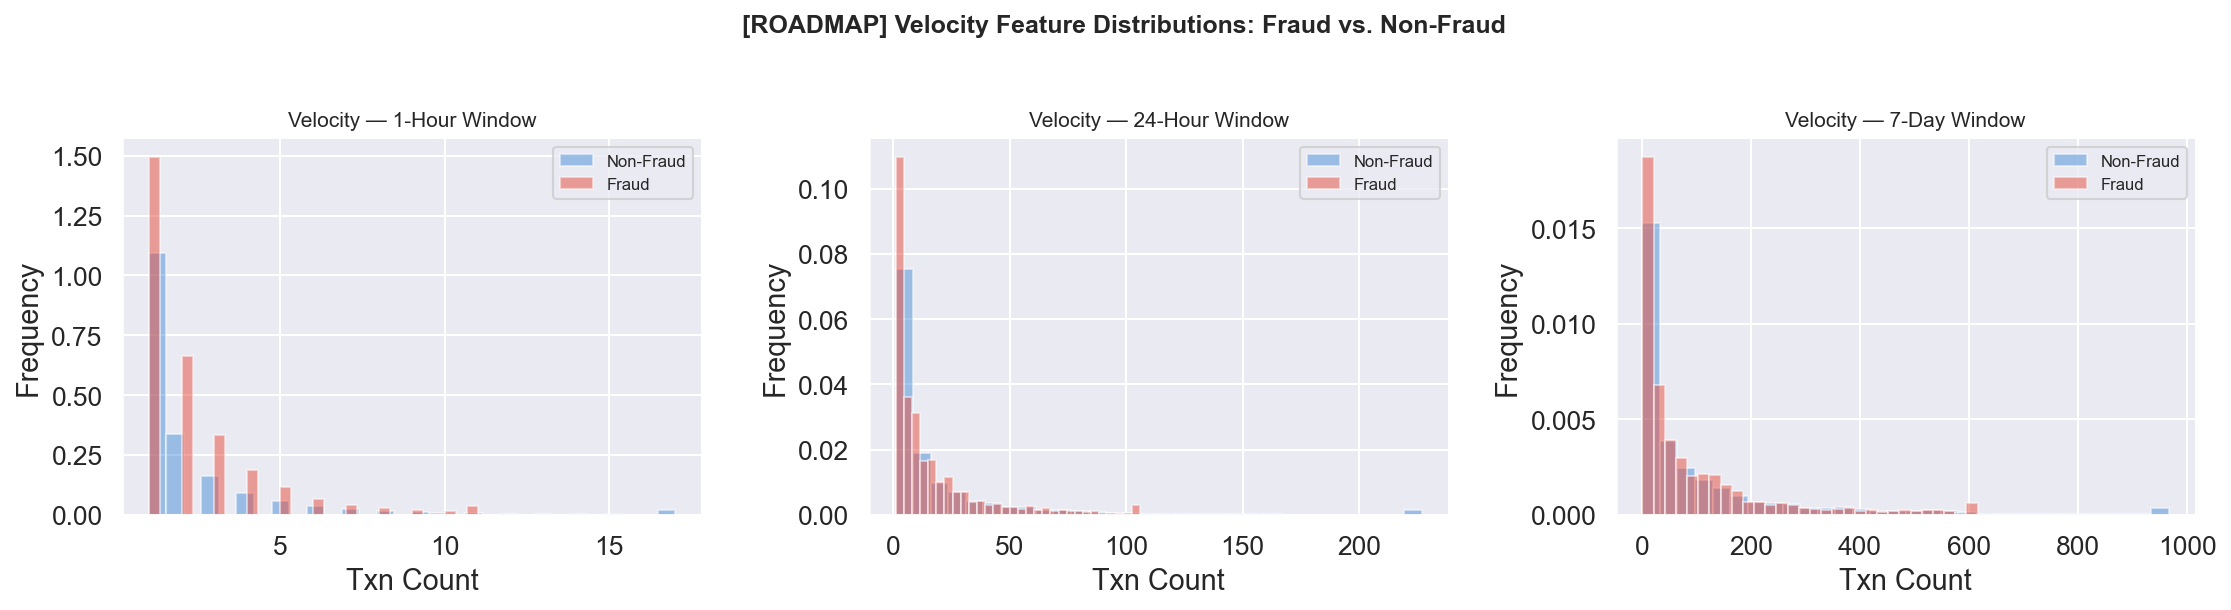

💾  Saved → 11_velocity_distributions.png


In [12]:
vel_cols = ["card1_txn_count_1h", "card1_txn_count_24h", "card1_txn_count_7d"]
titles   = ["1-Hour Window", "24-Hour Window", "7-Day Window"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, vel_cols, titles):
    for label, grp in df.groupby("isFraud"):
        color = "#E74C3C" if label == 1 else "#4A90D9"
        lbl   = "Fraud" if label == 1 else "Non-Fraud"
        data  = grp[col].clip(0, grp[col].quantile(0.99))
        data.plot.hist(ax=ax, bins=30, alpha=0.5, color=color, label=lbl, density=True)
    ax.set_title(f"Velocity — {title}", fontsize=10)
    ax.set_xlabel("Txn Count")
    ax.legend(fontsize=8)

plt.suptitle("[ROADMAP] Velocity Feature Distributions: Fraud vs. Non-Fraud",
             fontsize=12, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/11_velocity_distributions.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("💾  Saved → 11_velocity_distributions.png")


###### =============================================================================
###### SOURCE B — YOUR ROADMAP
###### Ratio Features: txn_amt ÷ mean_card_amt
###### =============================================================================

###### %% ---------------------------------------------------------------------------
#### CELL 6 — [ROADMAP] Ratio Features: Amount vs. Card Historical Mean
###### ------------------------------------------------------------------------------
###### Ratio = how unusual is THIS transaction amount relative to what this card
###### typically spends? A ratio >> 1 means unusually large → fraud signal.
######
###### Features created:
######   amt_ratio_to_card1_mean  : TransactionAmt / card1's historical mean amount
######   amt_ratio_to_card1_median: TransactionAmt / card1's historical median amount
######
###### "Historical" = computed on the full training set (no leakage concern for EDA;
###### for production use an expanding window or a pre-computed lookup table).

In [6]:
card1_stats = (
    df.groupby("card1")["TransactionAmt"]
    .agg(card1_mean_amt="mean", card1_median_amt="median", card1_std_amt="std")
    .reset_index()
)
df = df.merge(card1_stats, on="card1", how="left")

# Ratio features — add small epsilon to avoid division by zero
EPS = 1e-6
df["amt_ratio_to_card1_mean"]   = df["TransactionAmt"] / (df["card1_mean_amt"]   + EPS)
df["amt_ratio_to_card1_median"] = df["TransactionAmt"] / (df["card1_median_amt"] + EPS)

print("Ratio feature sample:")
print(df[["card1", "TransactionAmt", "card1_mean_amt",
          "amt_ratio_to_card1_mean", "amt_ratio_to_card1_median"]].head(6).round(3))

Ratio feature sample:
   card1  TransactionAmt  card1_mean_amt  amt_ratio_to_card1_mean  \
0  13926            68.5         351.931                    0.195   
1   2755            29.0         234.293                    0.124   
2   4663            59.0          97.016                    0.608   
3  18132            50.0         123.416                    0.405   
4   4497            50.0          96.972                    0.516   
5   5937            49.0         134.071                    0.365   

   amt_ratio_to_card1_median  
0                      0.457  
1                      0.257  
2                      1.000  
3                      0.834  
4                      0.459  
5                      0.419  


###### %% ---------------------------------------------------------------------------
#### CELL 7 — [ROADMAP] Ratio Feature Distribution Plot
###### ------------------------------------------------------------------------------
###### Fraud transactions with ratio >> 1 = large purchase after card-testing microtxns.
###### Ratio << 1 = micro-authorisation test against a card normally used for big buys.

KeyError: 'amt_ratio_to_card1_mean'

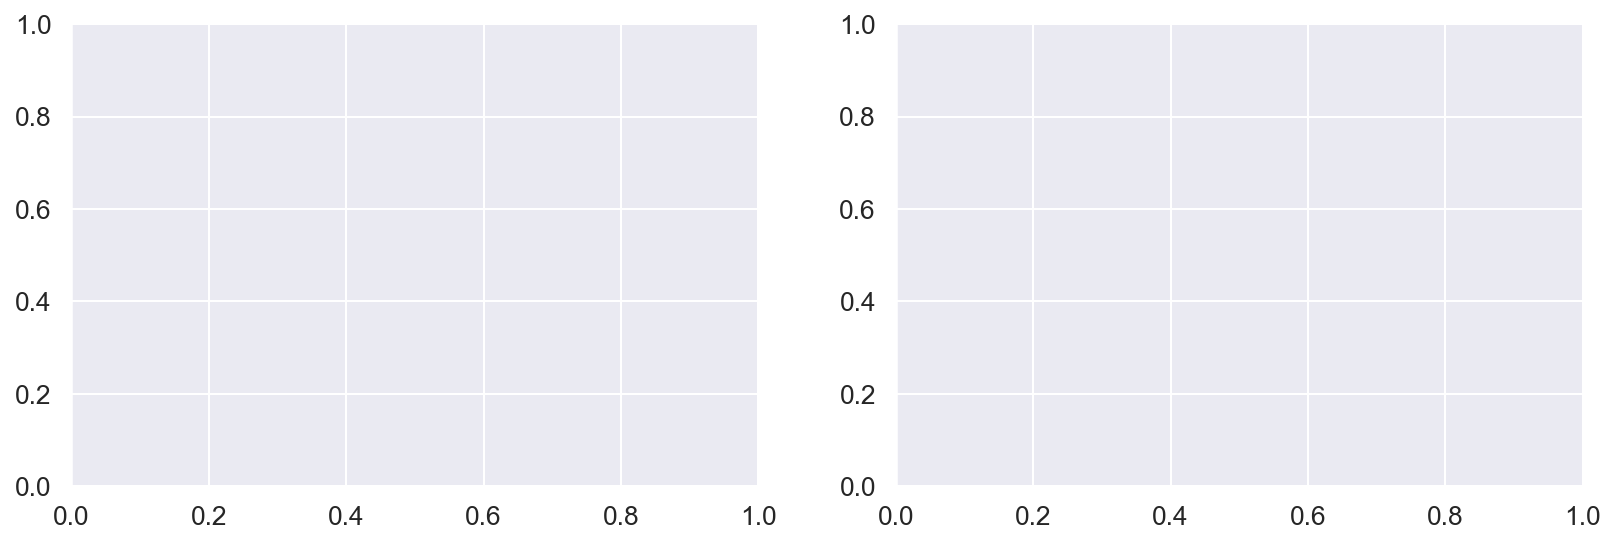

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ratio_cols = ["amt_ratio_to_card1_mean", "amt_ratio_to_card1_median"]
rtitles    = ["Amt / Card Mean", "Amt / Card Median"]

for ax, col, title in zip(axes, ratio_cols, rtitles):
    for label, grp in df.groupby("isFraud"):
        color = "#E74C3C" if label == 1 else "#4A90D9"
        lbl   = "Fraud" if label == 1 else "Non-Fraud"
        data  = np.log1p(grp[col].clip(0, grp[col].quantile(0.99)))
        data.plot.kde(ax=ax, color=color, label=lbl, lw=2)
    ax.set_title(f"[ROADMAP] Ratio Feature — {title} (log scale)", fontsize=10)
    ax.set_xlabel("log1p(ratio)")
    ax.legend(fontsize=8)

plt.suptitle("[ROADMAP] Amount Ratio Features: Fraud vs. Non-Fraud",
             fontsize=12, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/12_ratio_distributions.png", dpi=FIG_DPI, bbox_inches="tight")
plt.show()
print("💾  Saved → 12_ratio_distributions.png")


In [ ]:


# =============================================================================
# SOURCE C — YOUR ROADMAP
# Missing Value Strategy
# =============================================================================

# %% ---------------------------------------------------------------------------
# CELL 8 — [ROADMAP] Missing Value Strategy: Audit
# ------------------------------------------------------------------------------
# Three-tier strategy based on missing rate and column type:
#
#   Tier 1 — DROP   : >90% missing AND no fraud signal (check corr with isFraud)
#   Tier 2 — FLAG   : 50–90% missing identity columns → add {col}_is_null binary flag
#                     then impute with -999 sentinel (tree models handle this natively)
#   Tier 3 — IMPUTE : <50% missing numeric → median impute
#                     <50% missing categorical → mode impute or "UNKNOWN" string

miss_df = (
    df.isnull().mean()
      .rename("miss_rate")
      .reset_index()
      .rename(columns={"index": "feature"})
      .sort_values("miss_rate", ascending=False)
)
miss_df = miss_df[miss_df["miss_rate"] > 0]

# Classify each column into a tier
def classify_tier(row):
    if row["miss_rate"] > 0.90:
        return "Tier1_DROP_candidate"
    elif row["miss_rate"] >= 0.50:
        return "Tier2_FLAG+SENTINEL"
    else:
        return "Tier3_IMPUTE"

miss_df["strategy"] = miss_df.apply(classify_tier, axis=1)

tier_summary = miss_df["strategy"].value_counts()
print("[ROADMAP] Missing Value Strategy Tier Summary:")
print(tier_summary.to_string())
print(f"\nTotal columns with any missing: {len(miss_df)}")


# %% ---------------------------------------------------------------------------
# CELL 9 — [ROADMAP] Apply Missing Value Strategy
# ------------------------------------------------------------------------------
# Tier 2 identity columns: add _is_null flag BEFORE imputation so the model
# can learn "this feature was absent" as a signal in itself.
# Tree models (XGBoost/LightGBM) handle -999 sentinels natively — they will
# split on "< -998" vs. actual values automatically.

id_cols = [c for c in df.columns if c.startswith("id_") or
           c in ["DeviceType", "DeviceInfo"]]

# — Tier 2: Binary null flag + sentinel imputation -------------------------
tier2_cols = miss_df[miss_df["strategy"] == "Tier2_FLAG+SENTINEL"]["feature"].tolist()
tier2_cols = [c for c in tier2_cols if c in df.columns]

print(f"Tier 2 columns (FLAG + SENTINEL): {len(tier2_cols)}")
for col in tier2_cols:
    flag_col = f"{col}_is_null"
    df[flag_col] = df[col].isnull().astype(np.int8)
    if df[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
        df[col] = df[col].fillna(-999)
    else:
        df[col] = df[col].fillna("MISSING")

# — Tier 3: Median / mode imputation ---------------------------------------
tier3_cols = miss_df[miss_df["strategy"] == "Tier3_IMPUTE"]["feature"].tolist()
tier3_cols = [c for c in tier3_cols if c in df.columns]

print(f"Tier 3 columns (IMPUTE): {len(tier3_cols)}")
for col in tier3_cols:
    if df[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "UNKNOWN")

# — Tier 1: Flag candidates (do not drop yet — check corr first) -----------
tier1_cols = miss_df[miss_df["strategy"] == "Tier1_DROP_candidate"]["feature"].tolist()
print(f"\nTier 1 DROP candidates ({len(tier1_cols)} cols) — verifying fraud signal …")

tier1_corr = (
    df[[c for c in tier1_cols if c in df.select_dtypes(include=np.number).columns] + ["isFraud"]]
    .corrwith(df["isFraud"])
    .abs()
    .sort_values(ascending=False)
)
cols_to_drop = tier1_corr[tier1_corr < 0.01].index.tolist()
cols_to_keep = tier1_corr[tier1_corr >= 0.01].index.tolist()

print(f"  → Dropping {len(cols_to_drop)} cols (|corr| < 0.01)")
print(f"  → Keeping  {len(cols_to_keep)} cols despite high missingness (signal present)")

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

remaining_null = df.isnull().sum().sum()
print(f"\n✅  Remaining nulls after strategy: {remaining_null:,}")


# =============================================================================
# SOURCE D — SUGGESTED (Day 4 plan)
# Time-Since-Last-Transaction per card
# =============================================================================

# %% ---------------------------------------------------------------------------
# CELL 10 — [SUGGESTED] Time-Since-Last-Transaction per card1
# ------------------------------------------------------------------------------
# For each transaction, how many seconds since this card1 last transacted?
# First transaction per card gets NaN → imputed with global median (card is new).
#
# Why this matters: fraudsters run multiple transactions in rapid succession.
# time_since_last_txn << normal_interval → strong fraud signal.
# After Tier3 imputation above, we handle NaN here explicitly.

df["time_since_last_txn"] = (
    df.groupby("card1")["TransactionDT"]
      .diff()                          # seconds since previous txn on same card
      .fillna(df["TransactionDT"].median())   # first txn per card → global median
)

# Log transform — distribution is extremely right-skewed
df["time_since_last_txn_log"] = np.log1p(df["time_since_last_txn"])

print("[SUGGESTED] time_since_last_txn sample:")
print(df[["card1", "TransactionDT", "time_since_last_txn",
          "time_since_last_txn_log"]].head(8).round(2))

# Quick validation: fraud should have shorter time-since-last
print("\nMedian time_since_last_txn by class (seconds):")
print(df.groupby("isFraud")["time_since_last_txn"].median().round(1))


# %% ---------------------------------------------------------------------------
# CELL 11 — [SUGGESTED] Time-Since-Last-Txn Distribution Plot
# ------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 4))
for label, grp in df.groupby("isFraud"):
    color = "#E74C3C" if label == 1 else "#4A90D9"
    lbl   = "Fraud" if label == 1 else "Non-Fraud"
    grp["time_since_last_txn_log"].plot.kde(ax=ax, color=color, label=lbl, lw=2)

ax.set_title("[SUGGESTED] Time Since Last Transaction — KDE (log scale)", fontsize=12)
ax.set_xlabel("log1p(seconds since last txn on same card)")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/13_time_since_last_txn.png", dpi=FIG_DPI)
plt.show()
print("💾  Saved → 13_time_since_last_txn.png")


# =============================================================================
# SOURCE E — SUGGESTED (Day 4 plan)
# TransactionAmt Normalisation per card (Z-score)
# =============================================================================

# %% ---------------------------------------------------------------------------
# CELL 12 — [SUGGESTED] TransactionAmt Z-Score per card1
# ------------------------------------------------------------------------------
# Z-score = (this_amt - card_mean) / card_std
# Captures "how many standard deviations above/below is this transaction
# relative to THIS card's spending profile?"
#
# Difference from ratio feature (Source B):
#   Ratio  → relative magnitude (2× the mean)
#   Z-score → standardised deviation (3σ above mean = rare event)
# Both are kept — they capture complementary aspects of amount anomaly.

df["amt_zscore_card1"] = (
    (df["TransactionAmt"] - df["card1_mean_amt"])
    / (df["card1_std_amt"] + 1e-6)     # epsilon avoids division by zero for cards with 1 txn
)

print("[SUGGESTED] amt_zscore_card1 sample:")
print(df[["card1", "TransactionAmt", "card1_mean_amt",
          "card1_std_amt", "amt_zscore_card1"]].head(6).round(3))

print("\nMean amt_zscore_card1 by class:")
print(df.groupby("isFraud")["amt_zscore_card1"].mean().round(3))


# %% ---------------------------------------------------------------------------
# CELL 13 — [SUGGESTED] Z-Score Distribution Plot
# ------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 4))
for label, grp in df.groupby("isFraud"):
    color = "#E74C3C" if label == 1 else "#4A90D9"
    lbl   = "Fraud" if label == 1 else "Non-Fraud"
    data  = grp["amt_zscore_card1"].clip(-5, 10)
    data.plot.kde(ax=ax, color=color, label=lbl, lw=2)

ax.axvline(0, color="white", lw=1, ls="--")
ax.set_title("[SUGGESTED] TransactionAmt Z-Score per card1 — KDE", fontsize=12)
ax.set_xlabel("Z-score (clipped at [-5, 10])")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/14_amt_zscore_distribution.png", dpi=FIG_DPI)
plt.show()
print("💾  Saved → 14_amt_zscore_distribution.png")


# %% ---------------------------------------------------------------------------
# CELL 14 — Feature Engineering Summary: All New Columns
# ------------------------------------------------------------------------------
# Full audit of every feature created in this notebook, source-tagged.

new_features = {
    # Source A — Roadmap
    "card1_txn_count_1h"       : "ROADMAP | Velocity: txn count in last 1h per card1",
    "card1_txn_count_24h"      : "ROADMAP | Velocity: txn count in last 24h per card1",
    "card1_txn_count_7d"       : "ROADMAP | Velocity: txn count in last 7d per card1",
    # Source B — Roadmap
    "amt_ratio_to_card1_mean"  : "ROADMAP | Ratio: TransactionAmt / card1 mean amt",
    "amt_ratio_to_card1_median": "ROADMAP | Ratio: TransactionAmt / card1 median amt",
    # Source C — Roadmap
    "*_is_null flags"          : "ROADMAP | Missing: binary null flag for Tier2 identity cols",
    # Source D — Suggested
    "time_since_last_txn"      : "SUGGESTED | Seconds since card1's previous transaction",
    "time_since_last_txn_log"  : "SUGGESTED | log1p(time_since_last_txn)",
    # Source E — Suggested
    "amt_zscore_card1"         : "SUGGESTED | (TransactionAmt - card1_mean) / card1_std",
    # Temporal baseline (both sources use these)
    "hour_of_day"              : "BASELINE | Hour extracted from TransactionDatetime",
    "day_of_week"              : "BASELINE | Day of week (0=Mon)",
    "is_night"                 : "BASELINE | 1 if hour ∈ {0..4}",
    "is_weekend"               : "BASELINE | 1 if day ∈ {Sat, Sun}",
}

print("=" * 70)
print(f"{'Feature':<35} {'Source & Description'}")
print("=" * 70)
for feat, desc in new_features.items():
    print(f"{feat:<35} {desc}")
print("=" * 70)
print(f"\nTotal columns in engineered dataframe: {df.shape[1]:,}")


# %% ---------------------------------------------------------------------------
# CELL 15 — Persist Engineered Feature Parquet for Day 5
# ------------------------------------------------------------------------------
# Day 5 (XGBoost baseline) reads this file directly.
# We drop string/object columns that XGBoost can't handle natively —
# they will be label-encoded in a separate preprocessing step in Day 5.

cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols_to_drop = [c for c in cat_cols
                    if c not in ["ProductCD", "card4", "card6", "P_emaildomain",
                                 "R_emaildomain", "M1", "M2", "M3", "M4",
                                 "M5", "M6", "M7", "M8", "M9"]]

print(f"Dropping {len(cat_cols_to_drop)} unneeded object columns before saving …")
df_out = df.drop(columns=[c for c in cat_cols_to_drop if c in df.columns])

df_out.to_parquet(PARQUET_OUT, index=False)
print(f"\n✅  Engineered features saved → {PARQUET_OUT}")
print(f"    Shape: {df_out.shape[0]:,} rows × {df_out.shape[1]:,} columns")
print(f"    Size : {os.path.getsize(PARQUET_OUT)/1e6:.1f} MB")
print("\n🏁  Day 4 complete. Commit: 'FE: velocity + ratio features'")

# =============================================================================
# GIT COMMIT INSTRUCTIONS
# =============================================================================
# cd your-repo
# git add notebooks/fe_pt1_velocity_ratio.py outputs/fe_pt1/
# git commit -m "FE: velocity + ratio features"
# git push
